# SHAP to Explain Model Prediction: Loan Payback Case

## Package check and loading

In [ ]:
!pip list

In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import skops.io as sio
from joblib import dump
import shap
import random
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

## versions
# shap 0.49.1
# scikit-learn 1.6.1
# numpy 2.0.2
# pandas 2.2.2
# skops 0.13.0
# joblib 1.5.3

## Loading Data

In [9]:
model_path = '/kaggle/input/s5e11-remodel/scikitlearn/default/3/model.skops'
enc_path   = '/kaggle/input/s5e11-remodel/scikitlearn/default/3/encoder.skops'
unknown_model = sio.get_untrusted_types(file=model_path)
unknown_enc   = sio.get_untrusted_types(file=enc_path)
model = sio.load(model_path, trusted=unknown_model)
enc   = sio.load(  enc_path, trusted=unknown_enc)

data = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
data = data.drop('id', axis=1)
data = data.drop_duplicates()
X = data.copy().drop('loan_paid_back', axis=1)
y = data['loan_paid_back'].copy()

display(X.head())
display(y.head())

##print categories
print(enc.feature_names_in_)
print(enc.categories_)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1


0    1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: loan_paid_back, dtype: float64

['gender' 'marital_status' 'education_level' 'employment_status'
 'loan_purpose' 'grade_subgrade']
[array(['Male', 'Female'], dtype=object), array(['Single', 'Married', 'Divorced', 'Widowed'], dtype=object), array(['High School', "Bachelor's", "Master's", 'PhD'], dtype=object), array(['Self-employed', 'Employed', 'Unemployed', 'Retired', 'Student'],
      dtype=object), array(['Debt consolidation', 'Home', 'Education', 'Vacation', 'Car',
       'Medical', 'Business'], dtype=object), array(['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
       'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2',
       'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5'], dtype=object)]


## Data transformation

In [10]:
## transform things
objek = enc.feature_names_in_

X_ord = X[objek]
X_enc = enc.transform(X_ord)
X_enc = pd.DataFrame(X_enc, index=X.index,
                     columns=enc.get_feature_names_out())

## replace grade feature with encoded value
X = X.drop(objek, axis=1)
X = X.merge(X_enc, how='inner',
            left_index=True, right_index=True) ## use index as keys

## pick features due to feature selection
X = X[model.feature_names_in_]

display(X.head())

,debt_to_income_ratio,credit_score,loan_amount,marital_status,employment_status
0,0.084,736,2528.42,0.0,0.0
1,0.166,636,4593.10,1.0,1.0
2,0.097,694,17005.15,0.0,1.0
3,0.065,533,4682.48,0.0,1.0
4,0.053,665,12184.43,1.0,1.0


## Build SHAP Explainer and Feature Importance

,debt_to_income_ratio,credit_score,loan_amount,marital_status,employment_status
116739,0.176,611,15212.62,1.0,2.0
26225,0.080,771,17586.14,0.0,1.0
288389,0.094,598,12082.92,0.0,0.0
256787,0.039,732,12076.13,0.0,2.0
234053,0.067,671,27409.26,1.0,1.0


ExactExplainer explainer: 10001it [10:40, 15.44it/s]                           


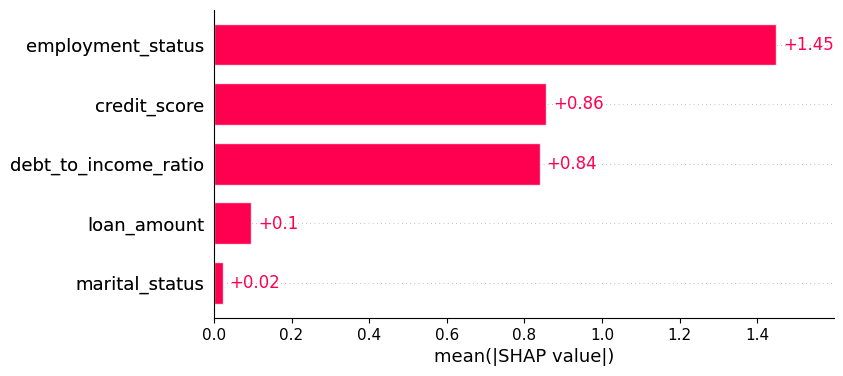

['shap_values.joblib']

In [11]:
## for simplicity, only take samples
ini_ind = [i for i in range(len(X))]
random.seed(42) ## seed
ini_sam = random.sample(ini_ind, 20000)
X_sam = X.loc[ini_sam,:]
# print(ini_sam)
display(X_sam.head())

## define function for model
def predict_log_proba(z):
    p = model.predict_proba(z)
    return np.log(p[:,1] / p[:,0])

def predict_proba(z):
    p = model.predict_proba(z)
    return p[:,1]

# do shap
background_data = shap.maskers.Independent(X_sam[:10000], max_samples=100)
explainer = shap.Explainer(predict_log_proba, background_data)
shap_values = explainer(X_sam[:10000])
shap.plots.bar(shap_values)

dump(explainer, 'explainer.joblib')
dump(shap_values, 'shap_values.joblib')

In [5]:
print(X_sam[:10000].dtypes.value_counts())

float64    4
int64      1
Name: count, dtype: int64


## PDP Plot

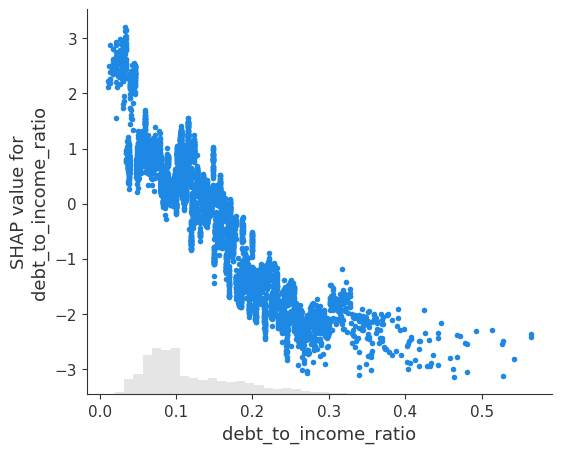

In [13]:
shap.plots.scatter(shap_values[:, "debt_to_income_ratio"])
# shap.plots.scatter(shap_values[:, "employment_status"])
# shap.plots.scatter(shap_values[:, "credit_score"])
# shap.plots.scatter(shap_values[:, "loan_amount"])
# shap.plots.scatter(shap_values[:, "marital_status"])